#Ch7 Regression



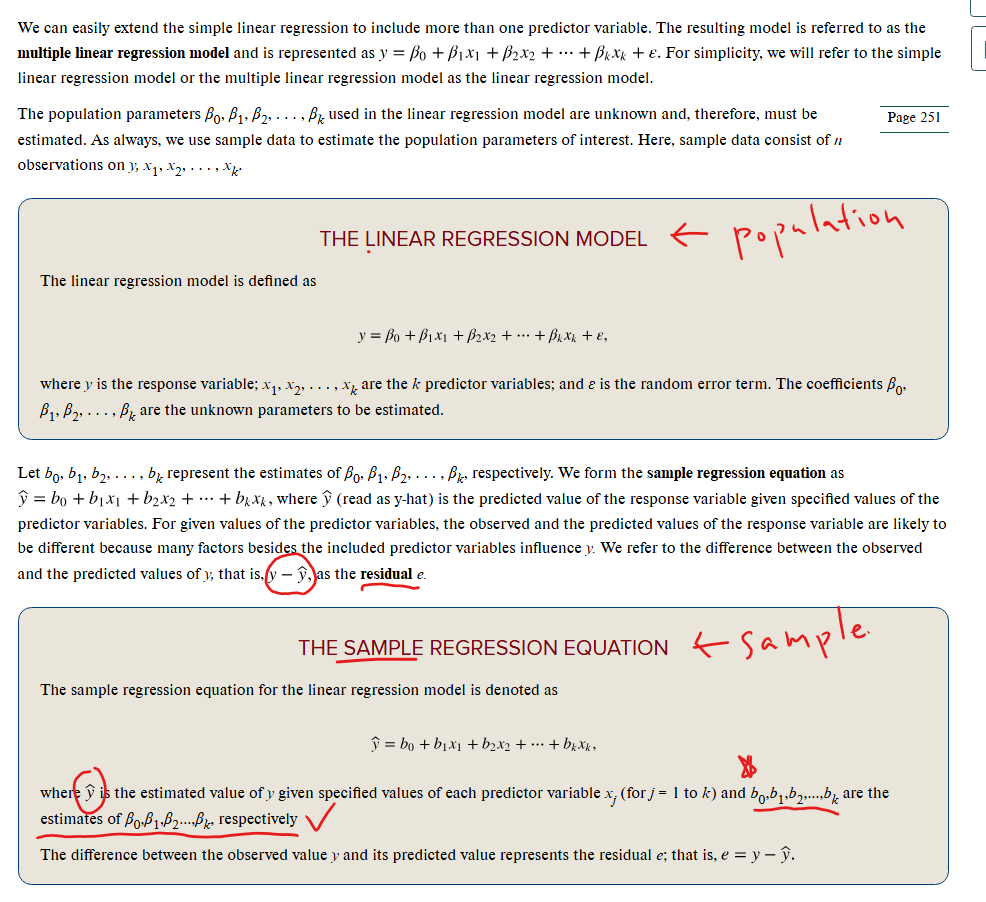

In [2]:
#mounnt your google dirve
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Example 7.1 (Section 7.1)

In [3]:
#Example 7.1

# Import the College data file and label it myData

import pandas as pd
myData = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/2510/2510-MH/MH-Ch7/jaggia_ba_2025_ch07_data.xlsx', sheet_name = 'College')
myData.head()




,School,Earnings,Cost,Grad,Debt,Location
0,St. Ambrose C (NC),44800,22920,62,88,City
1,"Albion College (Albion, MI)",45100,23429,73,92,Non-city
2,"Alfred University (Alfred, NY)",42300,19567,63,87,Non-city
3,"Allegheny College (Meadville, PA)",49200,25147,78,92,Non-city
4,"Beloit College (Beloit, WI)",37900,21979,78,93,City


In [4]:
# Creating City dummy variable

#This is called one hot encoding (City --> 1, Non-city --> 0)

# This is what our textbook used:
#Create the City column --> 1 for 'City, 0 for Non-city.

myData['City'] = myData['Location'].apply(lambda x: 1 if x == 'City' else 0)
myData.head()

,School,Earnings,Cost,Grad,Debt,Location,City
0,St. Ambrose C (NC),44800,22920,62,88,City,1
1,"Albion College (Albion, MI)",45100,23429,73,92,Non-city,0
2,"Alfred University (Alfred, NY)",42300,19567,63,87,Non-city,0
3,"Allegheny College (Meadville, PA)",49200,25147,78,92,Non-city,0
4,"Beloit College (Beloit, WI)",37900,21979,78,93,City,1


In [5]:
import numpy as np

# One hot encoding: method #2 (alternative way)

# Another way to create the City column --> 1 for 'City', 0 for Non-city

myData['City'] = np.where(myData['Location'] == 'City', 1, 0)
myData

,School,Earnings,Cost,Grad,Debt,Location,City
0,St. Ambrose C (NC),44800,22920,62,88,City,1
1,"Albion College (Albion, MI)",45100,23429,73,92,Non-city,0
2,"Alfred University (Alfred, NY)",42300,19567,63,87,Non-city,0
3,"Allegheny College (Meadville, PA)",49200,25147,78,92,Non-city,0
4,"Beloit College (Beloit, WI)",37900,21979,78,93,City,1
...,...,...,...,...,...,...,...
111,"Whittier College (Whittier, CA)",45100,33181,67,86,Non-city,0
112,"Widener University (Chester, PA)",51700,27387,56,83,Non-city,0
113,"Willamette University (Salem, OR)",49200,30312,78,93,City,1
114,"Winthrop University (Rock Hill, SC)",36100,15311,54,76,City,1


In [6]:
# Obtaining regression output
import statsmodels.formula.api as smf
Model = smf.ols('Earnings ~ Cost + Grad + Debt + City', data = myData).fit()
Model

In [7]:
print(Model.summary2())

                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.409     
Dependent Variable: Earnings         AIC:                2338.2548 
Date:               2025-11-18 20:12 BIC:                2352.0228 
No. Observations:   116              Log-Likelihood:     -1164.1   
Df Model:           4                F-statistic:        20.87     
Df Residuals:       111              Prob (F-statistic): 7.56e-13  
R-squared:          0.429            Scale:              3.1875e+07
-------------------------------------------------------------------
             Coef.     Std.Err.   t    P>|t|    [0.025     0.975]  
-------------------------------------------------------------------
Intercept  10004.9665 7634.3338 1.3105 0.1927 -5122.9757 25132.9086
Cost           0.4349    0.1110 3.9172 0.0002     0.2149     0.6549
Grad         178.0989   69.1940 2.5739 0.0114    40.9864   315.2114
Debt         141.4783  117.2120 1.2070 0.2300   -90.7851   373.741

In [ ]:
print(Model.predict(pd.DataFrame({'Cost': [25000], 'Grad': [60],'Debt': [80],'City': [1] })))

0    45408.799089
dtype: float64


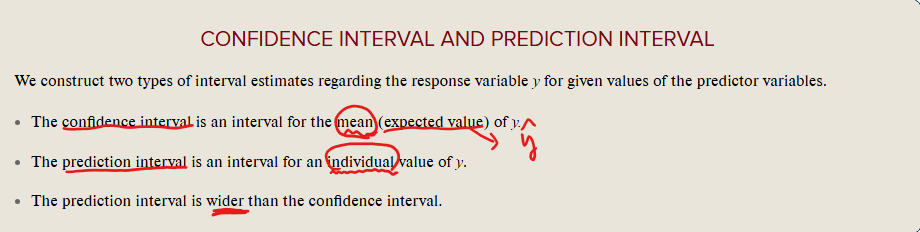

### Example 7.2  (Section 7.1)

In [8]:


import pandas as pd
myData = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/2510/2510-MH/MH-Ch7/jaggia_ba_2025_ch07_data.xlsx', sheet_name = 'College')
myData.head()


,School,Earnings,Cost,Grad,Debt,Location
0,St. Ambrose C (NC),44800,22920,62,88,City
1,"Albion College (Albion, MI)",45100,23429,73,92,Non-city
2,"Alfred University (Alfred, NY)",42300,19567,63,87,Non-city
3,"Allegheny College (Meadville, PA)",49200,25147,78,92,Non-city
4,"Beloit College (Beloit, WI)",37900,21979,78,93,City


In [9]:
# Creating City dummy variable --> City
# One hot encoding: method #1

myData['City'] = myData['Location'].apply(lambda x: 1 if x == 'City' else 0)



In [10]:
import numpy as np

# One hot encoding: method #2 (alternative way)

# Another way to create the City column --> 1 for 'City', 0 for Non-city

myData['City'] = np.where(myData['Location'] == 'City', 1, 0)
myData

,School,Earnings,Cost,Grad,Debt,Location,City
0,St. Ambrose C (NC),44800,22920,62,88,City,1
1,"Albion College (Albion, MI)",45100,23429,73,92,Non-city,0
2,"Alfred University (Alfred, NY)",42300,19567,63,87,Non-city,0
3,"Allegheny College (Meadville, PA)",49200,25147,78,92,Non-city,0
4,"Beloit College (Beloit, WI)",37900,21979,78,93,City,1
...,...,...,...,...,...,...,...
111,"Whittier College (Whittier, CA)",45100,33181,67,86,Non-city,0
112,"Widener University (Chester, PA)",51700,27387,56,83,Non-city,0
113,"Willamette University (Salem, OR)",49200,30312,78,93,City,1
114,"Winthrop University (Rock Hill, SC)",36100,15311,54,76,City,1


In [ ]:
import statsmodels.formula.api as smf
Model = smf.ols('Earnings ~ Cost + Grad + Debt + City', data = myData).fit()
print(Model.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     20.87
Date:                Thu, 13 Nov 2025   Prob (F-statistic):           7.56e-13
Time:                        23:19:17   Log-Likelihood:                -1164.1
No. Observations:                 116   AIC:                             2338.
Df Residuals:                     111   BIC:                             2352.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept       1e+04   7634.334      1.311      0.1

- Interpretation: If Cost is increased by one unit, the Earning is predicted to be increased by 0.43, holding the remaining variables (Grad, Debt and City) constant.

- Interpretation: If Grad is increased by one unit, the Earning (y_hat) is predicted to be increased by 178, holding the remaining variables (Cost, Debt, City) constant.


- y_hat (score) = 100 - 3* (playtime)
--> Interpretation: If playtime is increased by one unit, score is decreased by 3!




In [ ]:
# Note that get_prediction method is used
# note that alpha (level of significance = 0.05  (5%)) <---- summary_frame(alpha = 0.05)
# 5% significance level --> 95% confidence level (1-alpha = 1 - 0.05 = 0.95)

#95% Confidence Interval --[433392,  47424 ]
#95% Prediction Interval --[34041,   56776]
print(Model.get_prediction(pd.DataFrame({'Cost': [25000], 'Grad': [60],'Debt': [80],'City': [1]})).summary_frame(alpha = .05))

           mean      mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  45408.799089  1017.280834   43392.989207   47424.608971  34041.052382   

   obs_ci_upper  
0  56776.545796  


**Confidence interval** = about the average sandwich price

Question CI answers:

“On a day like this in this city, what is the average sandwich price?”

Example

Suppose we look at:

Weather: sunny, 75°F

City: Los Angeles

From the regression, we get:

Predicted mean price: $9.00

95% confidence interval for the mean: $8.50 to $9.5

How to read this:

“If we look at all sandwich shops in L.A. on sunny 75°F days, their average price is probably between $8.50 and $9.50.”

 **Prediction interval** = about one specific sandwich price

Now we compute a 95% prediction interval and get:

95% prediction interval for one new sandwich price: $6.00 to $12.00

How to read this:

“If I walk into one random sandwich shop in L.A. today (sunny, 75°F), its price will probably be between $6.00 and $12.00.”

This interval is **much wider** because:

- Different shops have different quality, rent, popularity, etc.

- Even on the same weather and in the same city, prices are all over the place.

So the PI includes:

- Uncertainty in the mean price (same as CI), plus

- Extra variation of individual shops around that mean
(some cheap shops, some fancy shops).

# Section 7.2



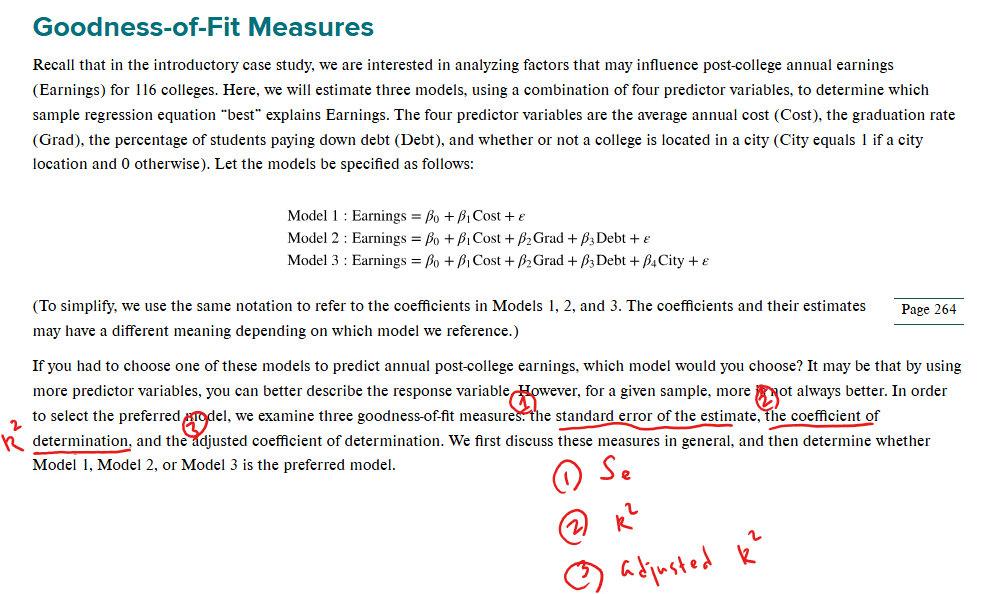

Think of the standard error of the estimate $S_e$ as:

- The typical size of your prediction error when you use the regression line.
(In the same units as your response variable.)
- About 68% of the osbservations will have residuals $y-\hat{y}$ between -$S_e$ and +$S_e$
- For example, $S_e = 2$: your predicions are typically off by about 2 units of y. With $S_e =10$, your prediction are typically off by about 10 units in y. Thus, It is a typical prediction error size.

R² tells you what fraction of the total sample variation in y (TSS) is explained by your regression model:

If R^2 = 0.80, that means
* 80% of how much the y's in the sample move around their mean is captured by the regression line
* The remaining 20% is still random noise/unexplained (residuals)


**Adjusted $R^2$**
 tells you how much it explains after penalizing you for using many predictors, so it’s better for judging whether extra variables are really helping.
 - Measures “fit per degree of freedom” (fit adjusted for model complexity).

- Can go up or down when you add predictors.

- Good for comparing models with different numbers of predictors:

- Higher adjusted $R^2$  → better balance of explanation vs. complexity.

- If you add a new variable and:
    * If $R^2$ ↑ and adjusted $R^2$ also ↑:  (adding the new) variable is likely useful.

    * If $R^2$ ↑ but adjusted $R^2$ ↓: (adding the new variable is probably not worth it (it doesn’t improve predictions enough to justify the extra complexity (adding extra variable).

### Example 7.4 (Chapter 7.2)

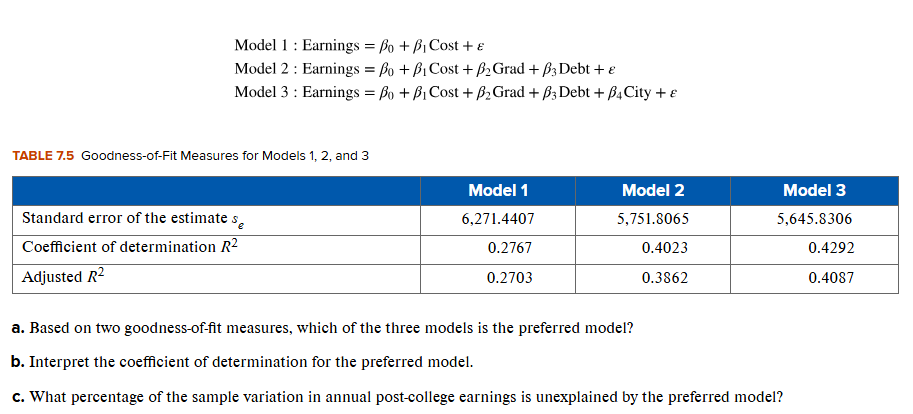

**Answers:**


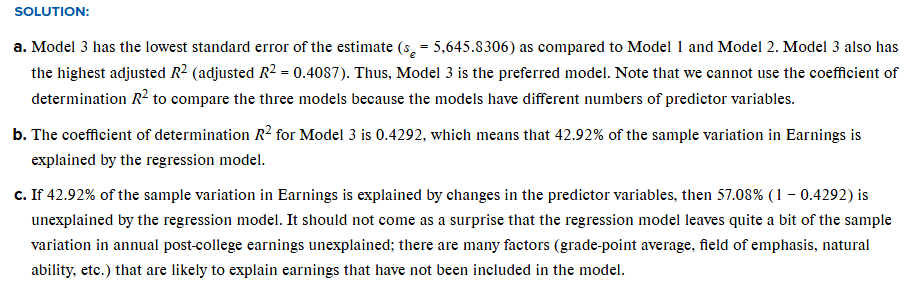

## More  Example (based on Exercise 7-19)

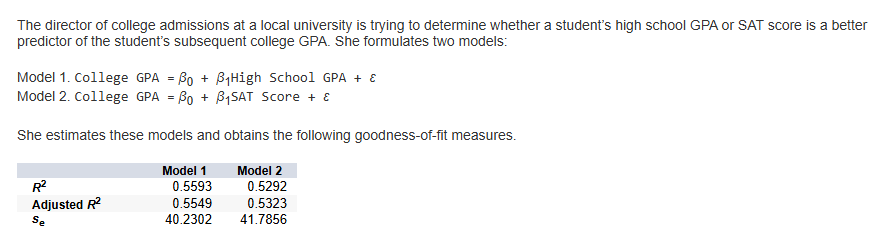

Which model provides a better fit for y?

Answer: Model 1 since it has a smaller standard error of the estimate and a higher coefficient of determination. We need not use adjusted R^2 since both models have the same number of predictor variables. Bsed on this analysis, it appers that high school GPA provides a better fit than SAT score.


# More example - R^2 - Based on Exercise 7-20

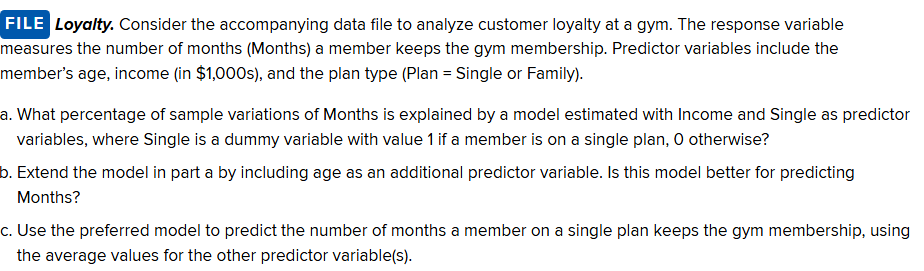

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd

myData = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/2510/2510-MH/MH-Ch7/jaggia_ba_2025_ch07_data.xlsx', sheet_name = 'Loyalty')

print(myData.head(n=10))

   Months  Age  Income    Plan
0      11   39     134  Single
1      41   57     120  Family
2      29   72      75  Single
3      52   71     143  Single
4      46   25      75  Single
5      48   44     149  Single
6       1   21     113  Family
7      54   26      87  Family
8      11   63      44  Family
9       3   37      44  Single


### Note that Single is a dummy variable with value 1 if a member is on a single plan, 0 otherwise.

In [12]:
myData['Single'] = myData['Plan'].apply(lambda x: 1 if x == 'Single' else 0)

print(myData.head())

   Months  Age  Income    Plan  Single
0      11   39     134  Single       1
1      41   57     120  Family       0
2      29   72      75  Single       1
3      52   71     143  Single       1
4      46   25      75  Single       1


In [13]:
import statsmodels.formula.api as smf

Model_1 = smf.ols('Months ~ Income + Single', data = myData).fit()


In [16]:
print(Model_1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Months   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     30.04
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           4.10e-12
Time:                        20:14:01   Log-Likelihood:                -824.92
No. Observations:                 200   AIC:                             1656.
Df Residuals:                     197   BIC:                             1666.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.5608      3.083      0.831      0.4

## If you care about full-precision values! (for your assignment --> round your answers to 2 decimal places!!)

In [17]:
print(Model_1.params) # full precision coefficients

Intercept    2.560786
Income       0.227623
Single      -2.070959
dtype: float64


In [18]:
print(Model_1.rsquared)  # R^2
print(Model_1.rsquared_adj) # R^2 adjusted

0.23371471403757837
0.22593516798719848


In [19]:
print(Model_1.bse)

Intercept    3.082739
Income       0.029464
Single       2.139499
dtype: float64


### The sample variance of the residual, $S_e$, also known as the standard error of the estimate:

In [ ]:
import numpy as np
#The standard error is NOT shown in the summary table above. Thus, we need to use mse_resid:
np.sqrt(Model_1.mse_resid) #standard error of the estimate

np.float64(15.077348119612862)

### Model 1 -->
* what percentage of sample variations of months is explained by a model 1 estimated with income and Single as predictor variables, where Single is a dummy variable with value 1 if a memer is on a single plan 0 otherwise.
* Answer --> find R^2 value from the summary table

### Model 2 (extended from the model 1)
*   Extended the model_1 by including age as an additional predictor variable ==> model_2

*   Note that the model_2 is better for predicting mothns because of its higher adjusted R^2 and standard error.




In [ ]:
Model_2 = smf.ols('Months ~ Income+ Single +Age', data = myData).fit()

print(Model_2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Months   R-squared:                       0.290
Model:                            OLS   Adj. R-squared:                  0.279
Method:                 Least Squares   F-statistic:                     26.65
Date:                Tue, 18 Nov 2025   Prob (F-statistic):           1.68e-14
Time:                        11:07:29   Log-Likelihood:                -817.32
No. Observations:                 200   AIC:                             1643.
Df Residuals:                     196   BIC:                             1656.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -8.4114      4.079     -2.062      0.0

In [ ]:
import numpy as np
#The standard error is NOT shown in the summary table above. Thus, we need to use mse_resid:
np.sqrt(Model_1.mse_resid) #standard error of the estimate

np.float64(15.077348119612862)

Model_2 is preferred. Why?


*   The standard error of the model_2 is smaller
*   Adjusted R^2 of the model_2 is smaller



In [ ]:
#What is the output of the model_2 if Income = average_income, single = 1, and Age = average_age



print(Model_2.predict(pd.DataFrame({'Income': [myData.Income.mean()], 'Single': [1], 'Age':[myData.Age.mean()]})))

0    21.12918
dtype: float64
